# Reconstruction efficiency

This notebook computes reconstruction efficiency as

$$\epsilon_\mathrm{reco}(x)=\frac{N_\mathrm{Atm}(x)}{N_\mathrm{AllEvents}(x)}$$

where `ana/Atm` contains reconstructed events and `ana/AllEvents` contains all simulated events. The deposited energy is computed from generated particles as the sum of `MCKineticEnergy` for non-neutrino PDG codes. Energy bins are logarithmically spaced from 0.1 to 100 GeV to match the sample binning.


In [17]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import uproot

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'plot_reco_efficiency.py').exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str(NOTEBOOK_DIR / 'ValidationStudies'))

import plot_reco_efficiency
plot_reco_efficiency = importlib.reload(plot_reco_efficiency)

ROOT_FILE = plot_reco_efficiency.ROOT_FILE
OUTDIR = plot_reco_efficiency.OUTDIR
NEUTRINO_ENERGY_BINS = plot_reco_efficiency.NEUTRINO_ENERGY_BINS
DEPOSITED_ENERGY_BINS = plot_reco_efficiency.DEPOSITED_ENERGY_BINS
efficiency = plot_reco_efficiency.efficiency
histogram_tree = plot_reco_efficiency.histogram_tree
plot_efficiency = plot_reco_efficiency.plot_efficiency

print(f'Neutrino energy bins: {NEUTRINO_ENERGY_BINS[0]:.3g} to {NEUTRINO_ENERGY_BINS[-1]:.3g} GeV, {len(NEUTRINO_ENERGY_BINS) - 1} log bins')
print(f'Deposited energy bins: {DEPOSITED_ENERGY_BINS[0]:.3g} to {DEPOSITED_ENERGY_BINS[-1]:.3g} GeV, {len(DEPOSITED_ENERGY_BINS) - 1} log bins')

plt.style.use('default')


Neutrino energy bins: 0.1 to 100 GeV, 60 log bins
Deposited energy bins: 0.1 to 100 GeV, 60 log bins


In [18]:
root_file = uproot.open(ROOT_FILE)
reco_tree = root_file['ana/Atm']
sim_tree = root_file['ana/AllEvents']

print(f'Reconstructed entries in ana/Atm:      {reco_tree.num_entries:,}')
print(f'Simulated entries in ana/AllEvents:    {sim_tree.num_entries:,}')
print(f'Inclusive reconstruction efficiency:   {reco_tree.num_entries / sim_tree.num_entries:.4f}')

Reconstructed entries in ana/Atm:      1,128,767
Simulated entries in ana/AllEvents:    1,500,000
Inclusive reconstruction efficiency:   0.7525


In [19]:
hist_nu_reco = histogram_tree(reco_tree, 'nu_energy', NEUTRINO_ENERGY_BINS)
hist_nu_sim = histogram_tree(sim_tree, 'nu_energy', NEUTRINO_ENERGY_BINS)

eff_nu, err_nu = efficiency(hist_nu_reco, hist_nu_sim)
list(zip(NEUTRINO_ENERGY_BINS[:-1], NEUTRINO_ENERGY_BINS[1:], hist_nu_reco, hist_nu_sim, eff_nu, err_nu))[:5]

[(0.1,
  0.11220184543019636,
  516.0,
  6167.0,
  0.08367115291065348,
  0.003525953510260659),
 (0.11220184543019636,
  0.12589254117941673,
  1076.0,
  9110.0,
  0.11811196487376509,
  0.0033813839265562804),
 (0.12589254117941673,
  0.14125375446227545,
  2203.0,
  11055.0,
  0.19927634554500226,
  0.0037991796544976524),
 (0.14125375446227545,
  0.15848931924611134,
  3205.0,
  14736.0,
  0.21749457111834963,
  0.0033984280816968075),
 (0.15848931924611134,
  0.1778279410038923,
  4757.0,
  18533.0,
  0.256677278368316,
  0.0032085554870840537)]

In [20]:
hist_dep_reco = histogram_tree(reco_tree, 'deposited_energy', DEPOSITED_ENERGY_BINS)
hist_dep_sim = histogram_tree(sim_tree, 'deposited_energy', DEPOSITED_ENERGY_BINS)

eff_dep, err_dep = efficiency(hist_dep_reco, hist_dep_sim)
list(zip(DEPOSITED_ENERGY_BINS[:-1], DEPOSITED_ENERGY_BINS[1:], hist_dep_reco, hist_dep_sim, eff_dep, err_dep))[:5]

[(0.1,
  0.11220184543019636,
  7132.0,
  19096.0,
  0.37348135735232507,
  0.00350050143830484),
 (0.11220184543019636,
  0.12589254117941673,
  8455.0,
  20211.0,
  0.41833654940379,
  0.003469803586264429),
 (0.12589254117941673,
  0.14125375446227545,
  10379.0,
  21539.0,
  0.48187009610474024,
  0.00340464275682886),
 (0.14125375446227545,
  0.15848931924611134,
  12408.0,
  22337.0,
  0.5554908895554461,
  0.0033248065498758007),
 (0.15848931924611134,
  0.1778279410038923,
  14754.0,
  23730.0,
  0.6217446270543616,
  0.003148108588624771)]

In [21]:
OUTDIR.mkdir(parents=True, exist_ok=True)

plot_efficiency(
    NEUTRINO_ENERGY_BINS,
    hist_nu_reco,
    hist_nu_sim,
    r'True neutrino energy $E_\nu$ [GeV]',
    OUTDIR / 'reco_efficiency_vs_neutrino_energy.png',
)

plot_efficiency(
    DEPOSITED_ENERGY_BINS,
    hist_dep_reco,
    hist_dep_sim,
    'Deposited energy from generated particles [GeV]',
    OUTDIR / 'reco_efficiency_vs_deposited_energy.png',
)

print(f'Wrote plots to {OUTDIR}')

Wrote plots to /home/leoperes/Desktop/UpperLimitCodeBDMv4/UpperLimitCodeBDM/ValidationStudies/plots/reco_efficiency


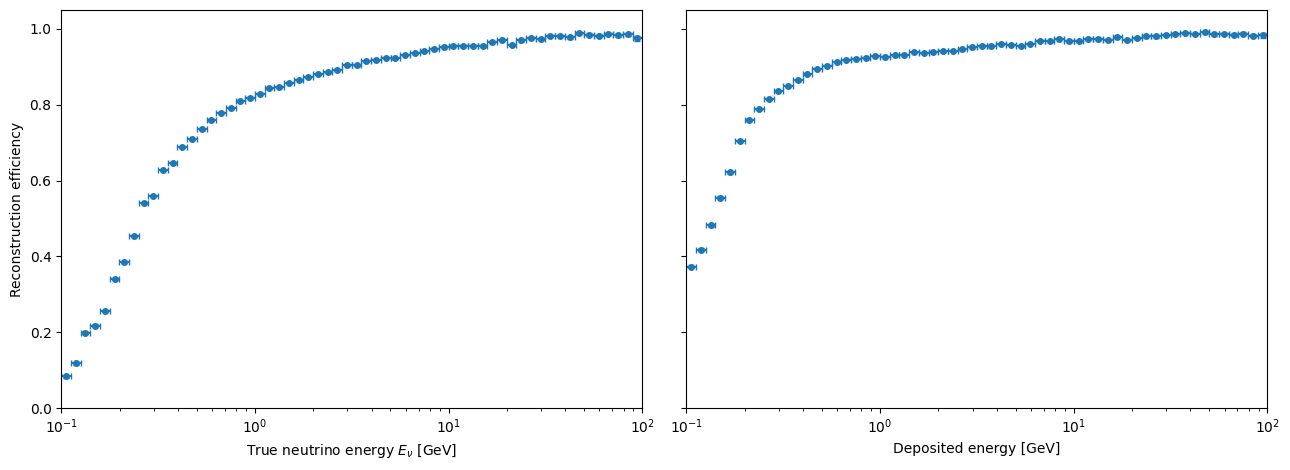

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, bins, eff, err, xlabel in [
    (axes[0], NEUTRINO_ENERGY_BINS, eff_nu, err_nu, r'True neutrino energy $E_\nu$ [GeV]'),
    (axes[1], DEPOSITED_ENERGY_BINS, eff_dep, err_dep, 'Deposited energy [GeV]'),
]:
    centers = np.sqrt(bins[:-1] * bins[1:])
    xerr = np.vstack([centers - bins[:-1], bins[1:] - centers])
    ax.errorbar(centers, eff, xerr=xerr, yerr=err, fmt='o', markersize=4, capsize=2)
    ax.set_xscale('log')
    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel(xlabel)
    

axes[0].set_ylabel('Reconstruction efficiency')
axes[0].set_ylim(0, 1.05)
fig.tight_layout()
